In [1]:
import pandas  as pd
import numpy as np
import seaborn as sn
import os

In [2]:
df = pd.read_csv("D:\Sales_Data\Sales_April_2019 (1).csv")
files = [file for file in os.listdir("D:\Sales_Data")]

all_month_data = pd.DataFrame()

for file in files:
    df = pd.read_csv(os.path.join("D:\Sales_Data",file))
    all_month_data = pd.concat([all_month_data, df], ignore_index = True)
all_month_data.to_csv(r"D:\Sales_Data\all_data.csv", index=False)

<>:1: SyntaxWarning: invalid escape sequence '\S'
<>:2: SyntaxWarning: invalid escape sequence '\S'
<>:7: SyntaxWarning: invalid escape sequence '\S'
<>:1: SyntaxWarning: invalid escape sequence '\S'
<>:2: SyntaxWarning: invalid escape sequence '\S'
<>:7: SyntaxWarning: invalid escape sequence '\S'
C:\Users\rajne\AppData\Local\Temp\ipykernel_11228\3889938275.py:1: SyntaxWarning: invalid escape sequence '\S'
  df = pd.read_csv("D:\Sales_Data\Sales_April_2019 (1).csv")
C:\Users\rajne\AppData\Local\Temp\ipykernel_11228\3889938275.py:2: SyntaxWarning: invalid escape sequence '\S'
  files = [file for file in os.listdir("D:\Sales_Data")]
C:\Users\rajne\AppData\Local\Temp\ipykernel_11228\3889938275.py:7: SyntaxWarning: invalid escape sequence '\S'
  df = pd.read_csv(os.path.join("D:\Sales_Data",file))


In [3]:
all_data = pd.read_csv("all_data.csv")
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,176559,Bose SoundSport Headphones,1,99.99,04-07-2019 22:30,"682 Chestnut St, Boston, MA 02215"
2,176560,Google Phone,1,600,04-12-2019 14:38,"669 Spruce St, Los Angeles, CA 90001"
3,176560,Wired Headphones,1,11.99,04-12-2019 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001"


## Question 1.  What was the best month for sales? How much was earned that month

In [6]:
all_data['Month'] = all_data['Order Date'].str[0:2]
all_data = all_data[all_data['Order Date'].str[0:2] != 'Or' ]
all_data['Month'] = all_data['Month'].astype('int32')

all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001",4
1,176559,Bose SoundSport Headphones,1,99.99,04-07-2019 22:30,"682 Chestnut St, Boston, MA 02215",4
2,176560,Google Phone,1,600,04-12-2019 14:38,"669 Spruce St, Los Angeles, CA 90001",4
3,176560,Wired Headphones,1,11.99,04-12-2019 14:38,"669 Spruce St, Los Angeles, CA 90001",4
4,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001",4


Clean up data with null value

In [5]:
nan_df = all_data[all_data.isna().any(axis=1)]
nan_df.head()

all_data = all_data.dropna(how='all')
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001",04
1,176559,Bose SoundSport Headphones,1,99.99,04-07-2019 22:30,"682 Chestnut St, Boston, MA 02215",04
2,176560,Google Phone,1,600,04-12-2019 14:38,"669 Spruce St, Los Angeles, CA 90001",04
3,176560,Wired Headphones,1,11.99,04-12-2019 14:38,"669 Spruce St, Los Angeles, CA 90001",04
4,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001",04


In [7]:
all_data.isnull().sum()

Order ID            0
Product             0
Quantity Ordered    0
Price Each          0
Order Date          0
Purchase Address    0
Month               0
dtype: int64

Task 3 Add a Sales Column

In [8]:
# Convert column from str to int or float
all_data['Quantity Ordered'] = pd.to_numeric(all_data['Quantity Ordered'], errors='coerce')
all_data['Price Each'] = pd.to_numeric(all_data['Price Each'], errors='coerce')

# Drop rows with NaN in either column
all_data.dropna(subset=['Quantity Ordered', 'Price Each'], inplace=True)

In [9]:
all_data['Quantity Ordered'] = pd.to_numeric(all_data['Quantity Ordered'], errors='coerce')
all_data['Price Each'] = pd.to_numeric(all_data['Price Each'], errors='coerce')

# Drop rows with NaN values
all_data.dropna(subset=['Quantity Ordered', 'Price Each'], inplace=True)


all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001",4
1,176559,Bose SoundSport Headphones,1,99.99,04-07-2019 22:30,"682 Chestnut St, Boston, MA 02215",4
2,176560,Google Phone,1,600.00,04-12-2019 14:38,"669 Spruce St, Los Angeles, CA 90001",4
3,176560,Wired Headphones,1,11.99,04-12-2019 14:38,"669 Spruce St, Los Angeles, CA 90001",4
4,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001",4


In [10]:
all_data['Sales'] = all_data['Quantity Ordered']*all_data['Price Each']
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001",4,23.90
1,176559,Bose SoundSport Headphones,1,99.99,04-07-2019 22:30,"682 Chestnut St, Boston, MA 02215",4,99.99
2,176560,Google Phone,1,600.00,04-12-2019 14:38,"669 Spruce St, Los Angeles, CA 90001",4,600.00
3,176560,Wired Headphones,1,11.99,04-12-2019 14:38,"669 Spruce St, Los Angeles, CA 90001",4,11.99
4,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001",4,11.99


Question 1. What was the best month for sales? How much was earned that month

In [48]:
results = all_data.groupby('Month')['Sales'].sum().reset_index()
results.head(100)

,Month,Sales
0,1,1822256.73
1,2,2202022.42
2,3,2807100.38
3,4,3390670.24
4,5,3152606.75
5,6,2577802.26
6,7,2647775.76
7,8,2244467.88
8,9,2097560.13
9,10,3736726.88


In [15]:
import matplotlib.pyplot as plt

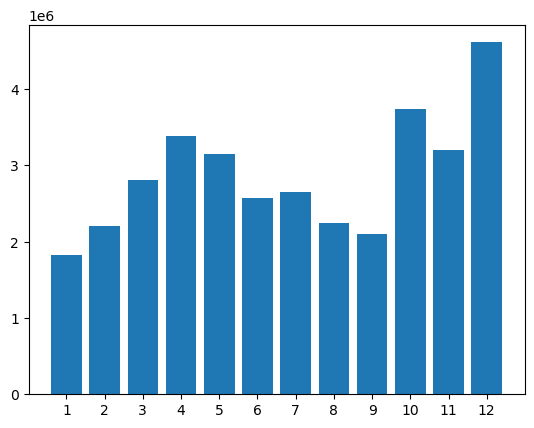

In [58]:
results = all_data.groupby('Month')['Sales'].sum().reset_index()
plt.bar(results['Month'], results['Sales'])
plt.xlabel = ('Months')
plt.ylabel = ('Sales in ($)')
plt.xticks(ticks =range(1,13),labels=range(1,13))
plt.show()

WHAT CITY HAS THE HIGHEST NUMBER OF SALES

In [13]:
#1.Add City coloumn
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001",4,23.90
1,176559,Bose SoundSport Headphones,1,99.99,04-07-2019 22:30,"682 Chestnut St, Boston, MA 02215",4,99.99
2,176560,Google Phone,1,600.00,04-12-2019 14:38,"669 Spruce St, Los Angeles, CA 90001",4,600.00
3,176560,Wired Headphones,1,11.99,04-12-2019 14:38,"669 Spruce St, Los Angeles, CA 90001",4,11.99
4,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001",4,11.99


In [14]:
all_data['City'] = all_data['Purchase Address'].apply(lambda x:x.split(',')[1])
all_data['City Code'] = all_data['Purchase Address'].apply(lambda x:x.split(',')[2])
                                 
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,City Code
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001",4,23.90,Dallas,TX 75001
1,176559,Bose SoundSport Headphones,1,99.99,04-07-2019 22:30,"682 Chestnut St, Boston, MA 02215",4,99.99,Boston,MA 02215
2,176560,Google Phone,1,600.00,04-12-2019 14:38,"669 Spruce St, Los Angeles, CA 90001",4,600.00,Los Angeles,CA 90001
3,176560,Wired Headphones,1,11.99,04-12-2019 14:38,"669 Spruce St, Los Angeles, CA 90001",4,11.99,Los Angeles,CA 90001
4,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001",4,11.99,Los Angeles,CA 90001


In [15]:
re = all_data.groupby(['City','City Code'])['Sales'].sum().reset_index()
re = re.sort_values(by = 'Sales', ascending = False) 
re.head(50)

,City,City Code,Sales
8,San Francisco,CA 94016,8262203.91
4,Los Angeles,CA 90001,5452570.80
5,New York City,NY 10001,4664317.43
2,Boston,MA 02215,3661642.01
0,Atlanta,GA 30301,2795498.58
3,Dallas,TX 75001,2767975.40
9,Seattle,WA 98101,2747755.48
7,Portland,OR 97035,1870732.34
1,Austin,TX 73301,1819581.75
6,Portland,ME 04101,449758.27


In [158]:
all_data['City'] = all_data['City'].astype(str)

In [16]:
print(re[['City', 'Sales']].head())

             City       Sales
8   San Francisco  8262203.91
4     Los Angeles  5452570.80
5   New York City  4664317.43
2          Boston  3661642.01
0         Atlanta  2795498.58


In [17]:
print(all_data[['City','Sales']].isna().sum())
print(all_data[all_data['City'].isna()].head())
all_data_clean = all_data.dropna(subset=['City','Sales'])

City     0
Sales    0
dtype: int64
Empty DataFrame
Columns: [Order ID, Product, Quantity Ordered, Price Each, Order Date, Purchase Address, Month, Sales, City, City Code]
Index: []


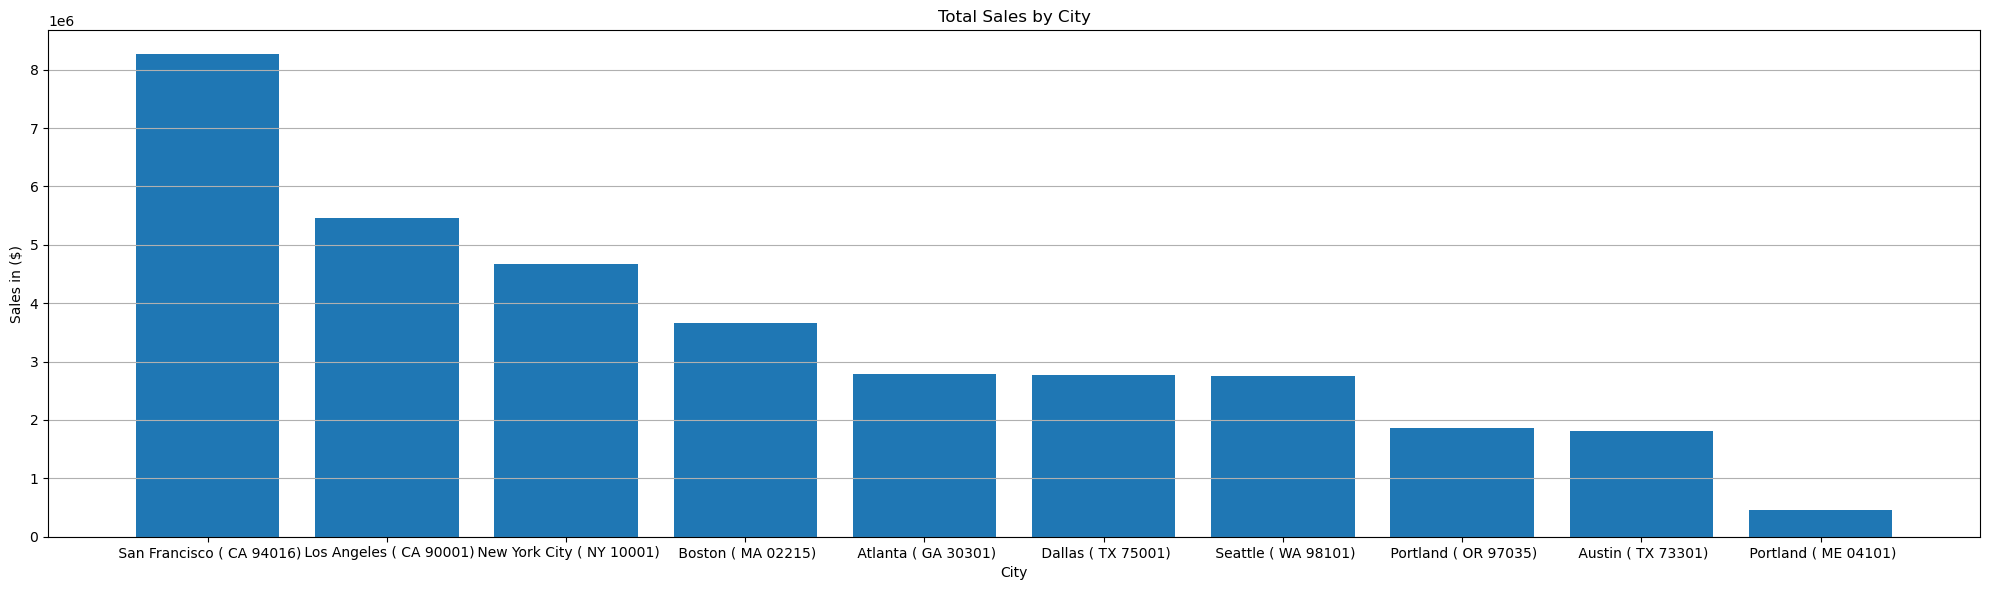

In [20]:
# Step 1: Drop missing values
all_data_clean = all_data.dropna(subset=['City', 'Sales'])

# Step 2: Group and sum sales
re = all_data_clean.groupby(['City', 'City Code'])['Sales'].sum().reset_index()

# Step 3: Sort
re = re.sort_values(by='Sales', ascending=False)

# Step 4: Create label for plotting
re['Label'] = re['City'] + ' (' + re['City Code'].astype(str) + ')'

# Step 5: Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(20,6))
plt.bar(re['Label'], re['Sales'])

plt.xlabel('City')
plt.ylabel('Sales in ($)')
plt.title('Total Sales by City')
plt.xticks(rotation=0)
plt.tight_layout()
plt.grid(axis='y')
plt.show()


In [21]:
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,City Code
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001",4,23.90,Dallas,TX 75001
1,176559,Bose SoundSport Headphones,1,99.99,04-07-2019 22:30,"682 Chestnut St, Boston, MA 02215",4,99.99,Boston,MA 02215
2,176560,Google Phone,1,600.00,04-12-2019 14:38,"669 Spruce St, Los Angeles, CA 90001",4,600.00,Los Angeles,CA 90001
3,176560,Wired Headphones,1,11.99,04-12-2019 14:38,"669 Spruce St, Los Angeles, CA 90001",4,11.99,Los Angeles,CA 90001
4,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001",4,11.99,Los Angeles,CA 90001


Question = What time should we display advertisment to maximize likelihood of customers buying products

In [22]:
all_data['Order Date'] = pd.to_datetime(all_data['Order Date'])

C:\Users\rajne\AppData\Local\Temp\ipykernel_11228\3842191188.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  all_data['Order Date'] = pd.to_datetime(all_data['Order Date'])


In [23]:
all_data['Hour'] = all_data['Order Date'].dt.hour 

In [24]:
all_data['Minutes'] = all_data['Order Date'].dt.minute

In [25]:
all_data['Hour'] = pd.to_numeric(all_data['Hour'])

In [26]:
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,City Code,Hour,Minutes
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",4,23.90,Dallas,TX 75001,8,46
1,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",4,99.99,Boston,MA 02215,22,30
2,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,600.00,Los Angeles,CA 90001,14,38
3,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,11.99,Los Angeles,CA 90001,14,38
4,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4,11.99,Los Angeles,CA 90001,9,27


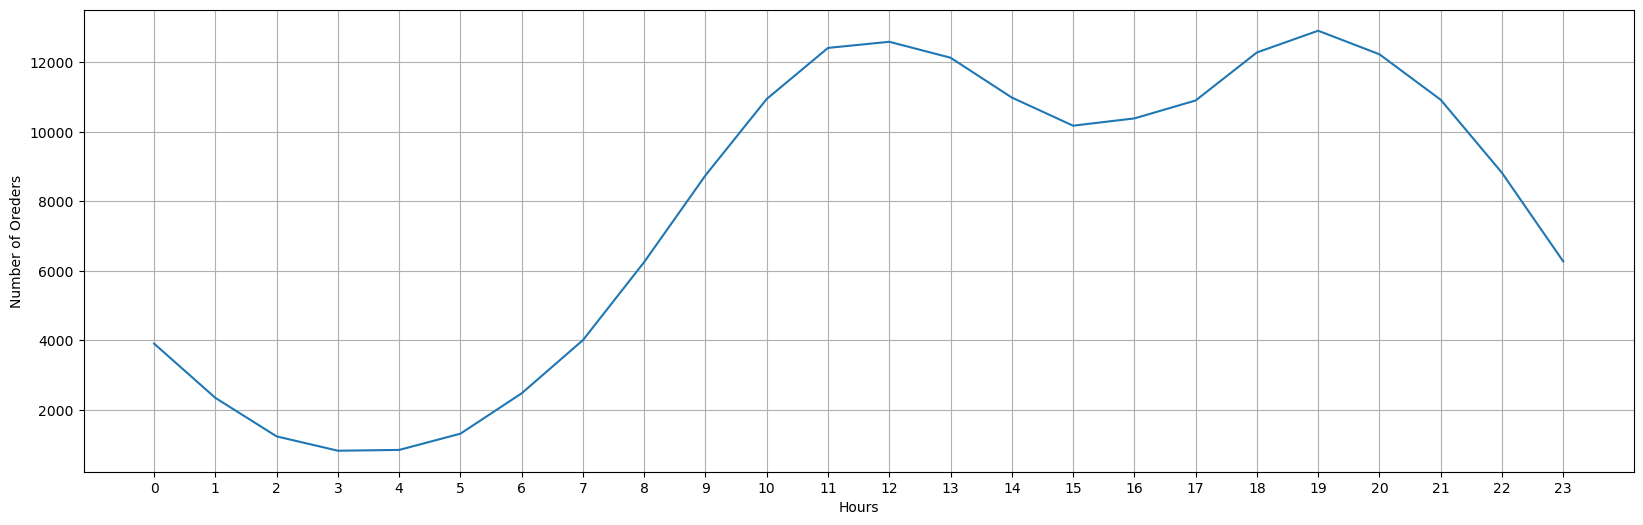

In [31]:
Hours = [Hour for Hour, df in all_data.groupby('Hour')]
order_count = all_data.groupby('Hour').count()['Order ID']
plt.figure(figsize=(20,6))
plt.plot(Hours , order_count)
plt.xlabel('Hours')
plt.ylabel('Number of Oreders')
plt.xticks(Hours)
plt.grid()
plt.show()

QUESTION 4 = What products are most often sold together

In [33]:
all_data['Product'] = all_data['Product'].astype(str)
all_data['Quantity Ordered'] = pd.to_numeric(all_data['Quantity Ordered'])
product_count = all_data.groupby('Product')['Quantity Ordered'].count().reset_index()
product_count = product_count.sort_values(by = 'Quantity Ordered' , ascending = False)
product_count.head(100)

,Product,Quantity Ordered
15,USB-C Charging Cable,21903
12,Lightning Charging Cable,21658
5,AAA Batteries (4-pack),20641
4,AA Batteries (4-pack),20577
17,Wired Headphones,18882
6,Apple Airpods Headphones,15549
7,Bose SoundSport Headphones,13325
2,27in FHD Monitor,7507
18,iPhone,6842
1,27in 4K Gaming Monitor,6230


In [34]:
df = all_data[all_data['Order ID'].duplicated(keep = False)]
df['Grouped'] = df.groupby('Order ID')['Product'].transform(lambda x:','.join(x))
df = df[['Order ID','Grouped']].drop_duplicates()
df.head(10)

C:\Users\rajne\AppData\Local\Temp\ipykernel_11228\3057166643.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Grouped'] = df.groupby('Order ID')['Product'].transform(lambda x:','.join(x))


,Order ID,Grouped
2,176560,"Google Phone,Wired Headphones"
17,176574,"Google Phone,USB-C Charging Cable"
29,176585,"Bose SoundSport Headphones,Bose SoundSport Hea..."
31,176586,"AAA Batteries (4-pack),Google Phone"
118,176672,"Lightning Charging Cable,USB-C Charging Cable"
128,176681,"Apple Airpods Headphones,ThinkPad Laptop"
137,176689,"Bose SoundSport Headphones,AAA Batteries (4-pack)"
188,176739,"34in Ultrawide Monitor,Google Phone"
224,176774,"Lightning Charging Cable,USB-C Charging Cable"
232,176781,"iPhone,Lightning Charging Cable"


In [35]:
from itertools import combinations
from collections import Counter

In [36]:
count = Counter()
for row in df['Grouped']:
    row_list = row.split(',')
    count.update(Counter(combinations(row_list,2)))

In [37]:
for key, value in count.most_common(10):
    print(key,value)

('iPhone', 'Lightning Charging Cable') 1005
('Google Phone', 'USB-C Charging Cable') 987
('iPhone', 'Wired Headphones') 447
('Google Phone', 'Wired Headphones') 414
('Vareebadd Phone', 'USB-C Charging Cable') 361
('iPhone', 'Apple Airpods Headphones') 360
('Google Phone', 'Bose SoundSport Headphones') 220
('USB-C Charging Cable', 'Wired Headphones') 160
('Vareebadd Phone', 'Wired Headphones') 143
('Lightning Charging Cable', 'Wired Headphones') 92


Question  - What product sold the most? Why do you think it sold the most?

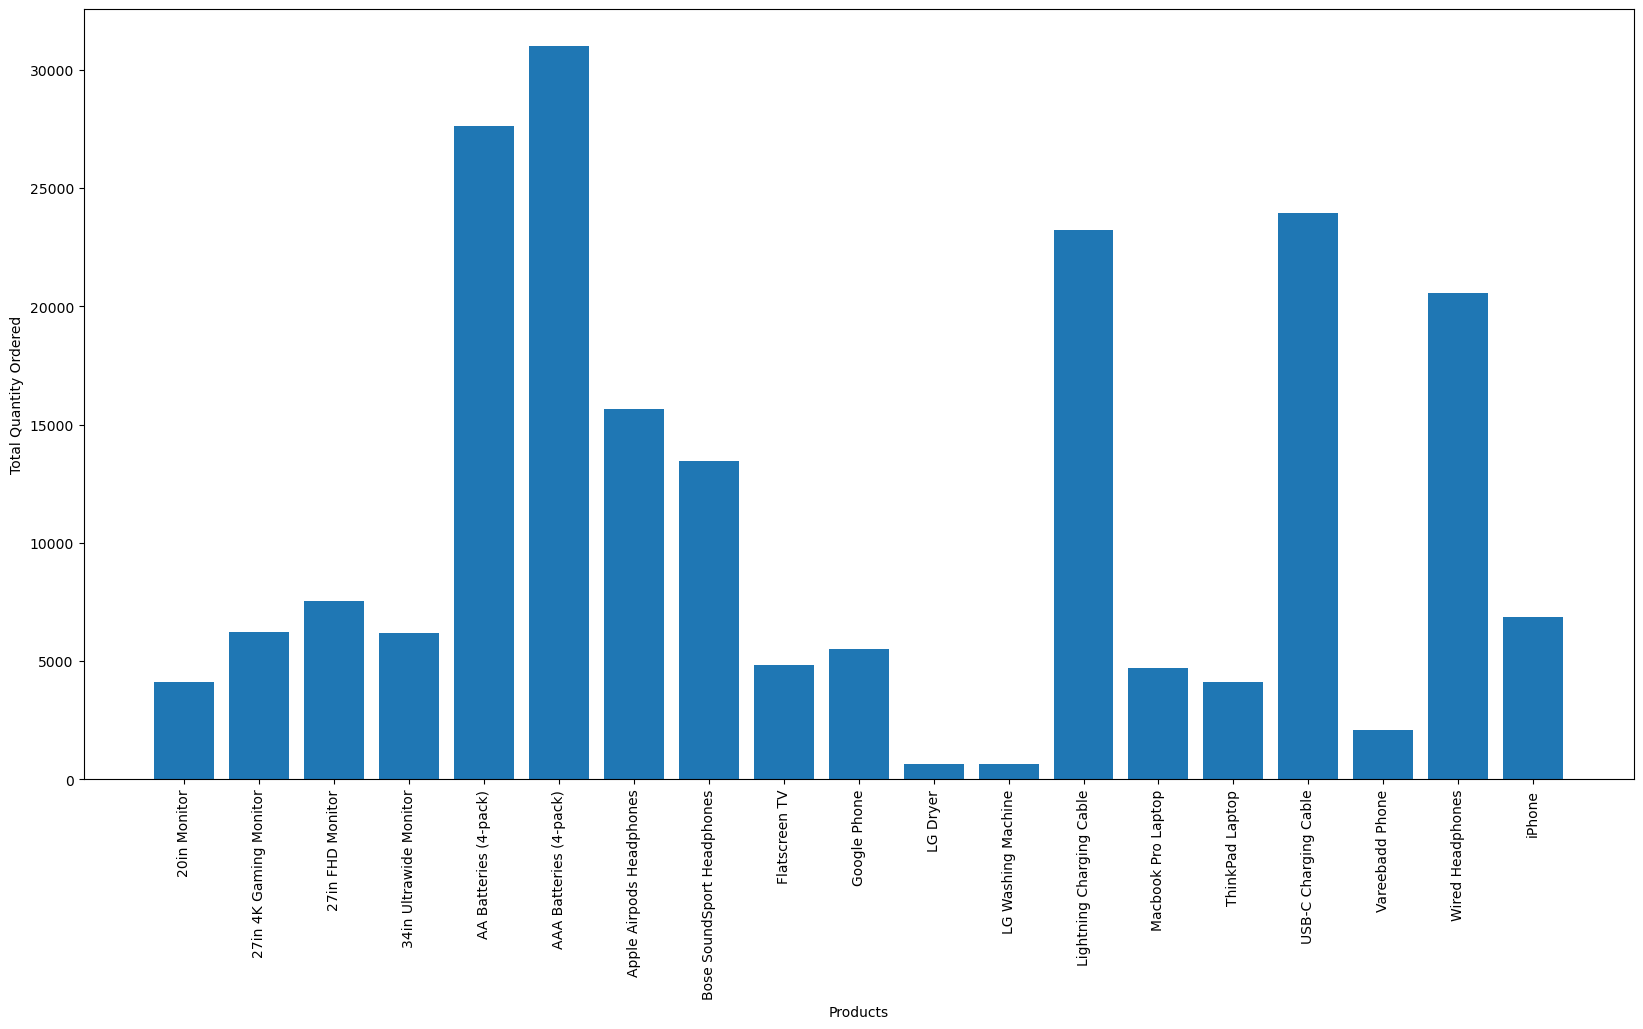

In [38]:
product_g = all_data.groupby('Product')['Quantity Ordered'].sum().reset_index()
plt.figure(figsize = (20,10))
plt.bar(product_g['Product'],product_g['Quantity Ordered'])
plt.xlabel('Products')
plt.ylabel('Total Quantity Ordered')
plt.xticks(rotation = 'vertical')
plt.show()
                

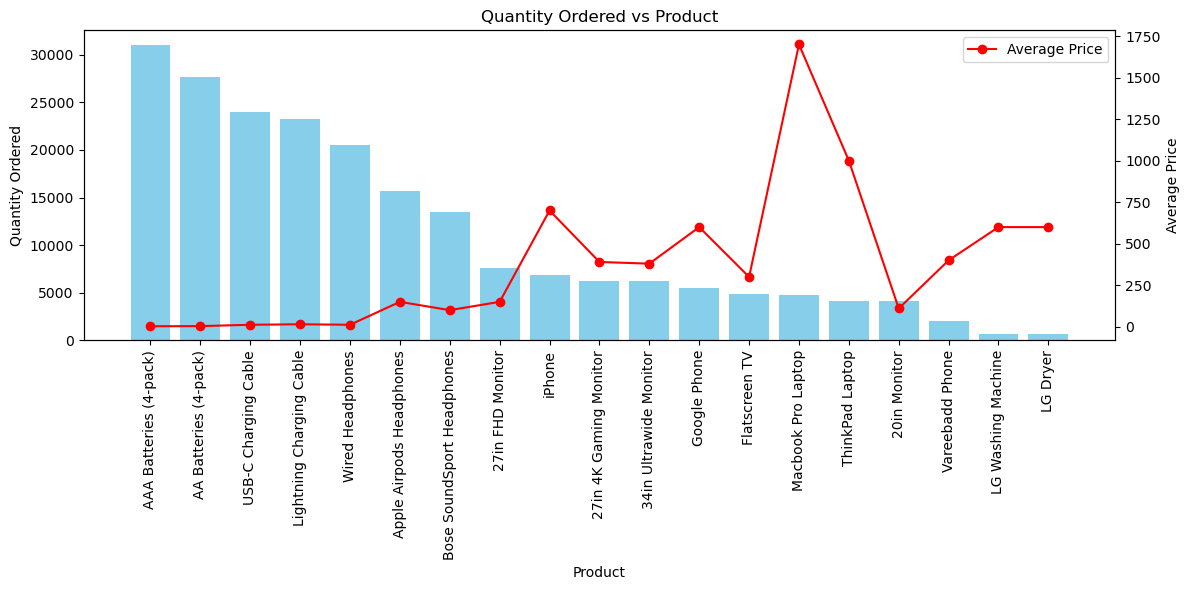

In [39]:

prices = all_data.groupby('Product')['Price Each'].mean().reset_index()

merged = pd.merge(product_g, prices, on='Product')

merged = merged.sort_values(by='Quantity Ordered', ascending=False)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.bar(merged['Product'], merged['Quantity Ordered'], color='skyblue', label='Quantity Ordered')
plt.xticks(rotation=90)
plt.ylabel('Quantity Ordered')
plt.xlabel('Product')
plt.title('Quantity Ordered vs Product')
plt.twinx() 
plt.plot(merged['Product'], merged['Price Each'], color='red', marker='o', label='Average Price')
plt.ylabel('Average Price')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()